# **Predicting Intoxication from Motion Data: A Machine Learning Analysis for JITAI Applications**

Authors: Salma El-Aazdoudi and Maria Micaela Linares Gómez

Excessive alcohol consumption is a major yet preventable public health risk. The university campus environment contributes to increased exposure to heavy drinking episodes, making students a high-risk population. Just-in-Time-Adaptative-Interventions (JITAIs), which send alerts when danger is highest, offer a promising way for prevention. Using data from thirteen campus students in the United States collected by Killian et al. (2019), this project builds nine machine learning models for real-time detection of alcohol intoxication based on smartphone accelerometer data. Models in four main families are here tested: linear models, support vector machines, tree-based methods and neural networks. Transdermal Alcohol Content (TAC) recordings, codified as 'intoxicated' when exceeding a value of 0.08 g/dl, are used to supervise learning (target). Our results suggest that movement consistency —regular gait patterns and motor control primarily captured by frequency domain features —is more predictive than movement intensity —how much individuals move reflected by time domain features. Tree-based methods consistently outperform linear models and a MLP, which we attribute to the tabular and 'chunky' nature of the data. Our two best performing models —a Random Forest and XGboost —achieve a 86.5\% accuracy and demonstrate a strong class discrimination capacity. However, an examination of misclassified instances highlights an important limitation: motor impairment alone can, in some cases, be an unreliable proxy for alcohol intoxication.

**This notebook is structured in five sections**:
- section 1 sets up the environment for model training and defines functions that are consistently used throughout the training and evaluation process ;
- section 2 loads the data, verifies its structure, and divides it into a train, a validation and a test set ;
- section 3 trains models using cross-validation for hyperparameter tuning using 'accuracy' as metric and assesses models' overall performance ;
- section 4 compares trained models' performance across different classification threasholds ;
- section 5 produces visualisations on the distribution of the raw Transdermal Alcohol Content (TAC) values as well as for the most predictive features for the misclassified instances by our two best performing models to understand where are they failing and how 'serious' are these mistakes.

## **1. Setup and Functions**

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.metrics import balanced_accuracy_score, make_scorer, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, auc, precision_recall_curve, fbeta_score, roc_curve
from sklearn.linear_model import RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.kernel_approximation import RBFSampler
import seaborn as sns


In [ ]:
# Definition of functions
# 1. Data train-validation-test split function
def split_dataset(dataset, seed=1):
    """
    Split dataset into train (70%), validation (15%), test (15%).
    """
    X = dataset.drop(columns=['pid', 'window10', 'timestamp', 'intoxicated', 'datetime', 'TAC_Reading'], axis=1)
    y = dataset[['intoxicated']]
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=seed,stratify=y)
    valid_X, test_X, valid_y, test_y = train_test_split(test_X, test_y, test_size=0.5, random_state=seed)
    return train_X, valid_X, test_X, train_y, valid_y, test_y

# 2. Evaluation metrics functions
def get_classification_metrics(model, X_test, y_test):
    """
    Calculates classification metrics.
    """

    # Predict the class labels
    y_pred = model.predict(X_test)

    # Predict probabilities
    try:
        y_proba = model.predict_proba(X_test)[:, 1]
    except AttributeError:
        # For models without predict_proba
        y_proba = model.decision_function(X_test)

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'F2 Score': fbeta_score(y_test, y_pred,beta=2),
        'Recall':recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred)
    }

    return metrics

# 3. Confusion metric plot function
def plot_confusion_matrix(model, X_test, y_test, title='Confusion Matrix'):
    """
    Generates and displays the Confusion Matrix.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1']
    )
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 4. ROC-AUC curve plotting function - specificity - sensitivity-specificity trade-off analysis
def plot_roc_curve_comparison(models, X_test, y_test, model_names):
    """
    Plots ROC curves for multiple models.
    """
    plt.figure(figsize=(8, 6))

    for model, name in zip(models, model_names):
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except AttributeError:

            y_proba = model.decision_function(X_test)

        y_test_array = np.array(y_test)
        y_proba_array = np.array(y_proba)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)

        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

# 5. Precision-Recall plotting function - precision-recall trade-off analysis
def plot_precision_recall_curves(models, X_test, y_test, models_names):
    """
    Plots the Precision-Recall curve for multiple classification models.
    """
    plt.figure(figsize=(10, 7))

    for model, name in zip(models, models_names):
        y_scores = None # Initialize y_scores

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test)
        else:
            print(f"Skipping {name}: Model does not have predict_proba or decision_function.")
            continue

        if y_scores is not None:
            precision, recall, _ = precision_recall_curve(y_test, y_scores)

            pr_auc = auc(recall, precision)

            plt.plot(recall, precision,
                     label=f'{name} (AP = {pr_auc:.3f})',
                     linewidth=2)


    prevalence = float(np.sum(y_test) / len(y_test))
    plt.plot([0, 1], [prevalence, prevalence],
             linestyle='--',
             color='gray',
             label=f'Baseline (AP = {prevalence:.3f})')

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve Comparison', fontsize=14)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True)
    plt.show()

## **2. Data Loading and Preparation**

In [ ]:
# Set working directory
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read processed data
PROJECT_FOLDER_NAME = 'ASML'
PROJECT_PATH=os.path.join('/content/drive/MyDrive/', PROJECT_FOLDER_NAME)
DATA_FILE_PATH = os.path.join(PROJECT_PATH,'Final_data', 'merged_data.csv')

In [ ]:
# Verify data
df = pd.read_csv(DATA_FILE_PATH)
df.head()

,pid,window10,x_mean,x_median,x_min,x_max,x_std,x_percentile_5,x_percentile_25,x_percentile_75,...,y_std_first3,z_mean_first3,z_median_first3,z_min_first3,z_max_first3,z_std_first3,timestamp,TAC_Reading,intoxicated,datetime
0,SA0297,149373388,-0.046270,-0.0026,-0.2888,0.1672,0.098936,-0.2427,-0.0202,0.0014,...,0.026359,-0.011375,-0.011833,-0.036933,0.005667,0.005126,1493732624,0.030566,0.0,2017-05-02 13:43:44
1,SA0297,149373389,0.007521,-0.0011,-0.2182,0.4063,0.067725,-0.0340,-0.0030,0.0017,...,0.005339,-0.001082,-0.002633,-0.056700,0.034500,0.019634,1493732624,0.030566,0.0,2017-05-02 13:43:44
2,SA0297,149373390,0.000888,-0.0002,-0.0107,0.2475,0.016792,-0.0052,-0.0022,0.0014,...,0.003269,-0.003082,-0.003050,-0.005567,0.001567,0.001655,1493732624,0.030566,0.0,2017-05-02 13:43:44
3,SA0297,149373391,0.000072,0.0001,-0.0124,0.0178,0.002788,-0.0041,-0.0014,0.0014,...,0.002325,-0.003131,-0.003067,-0.006267,-0.000600,0.001297,1493732624,0.030566,0.0,2017-05-02 13:43:44
4,SA0297,149373392,-0.000280,-0.0005,-0.0140,0.0128,0.002845,-0.0046,-0.0017,0.0011,...,0.004306,-0.002094,-0.001700,-0.005733,0.001100,0.001663,1493732624,0.030566,0.0,2017-05-02 13:43:44


In [ ]:
# Verify shape of the data
df.shape

(72521, 153)

In [ ]:
# Verify features names
print(df.columns.tolist())

['pid', 'window10', 'x_mean', 'x_median', 'x_min', 'x_max', 'x_std', 'x_percentile_5', 'x_percentile_25', 'x_percentile_75', 'x_percentile_95', 'x_zero_crossing', 'x_calculate_energy', 'x_energy_entropy', 'x_get_spectral_centroid', 'x_get_spectral_spread', 'y_mean', 'y_median', 'y_min', 'y_max', 'y_std', 'y_percentile_5', 'y_percentile_25', 'y_percentile_75', 'y_percentile_95', 'y_zero_crossing', 'y_calculate_energy', 'y_energy_entropy', 'y_get_spectral_centroid', 'y_get_spectral_spread', 'z_mean', 'z_median', 'z_min', 'z_max', 'z_std', 'z_percentile_5', 'z_percentile_25', 'z_percentile_75', 'z_percentile_95', 'z_zero_crossing', 'z_calculate_energy', 'z_energy_entropy', 'z_get_spectral_centroid', 'z_get_spectral_spread', 'x_mean_mean', 'x_mean_median', 'x_mean_min', 'x_mean_max', 'x_mean_std', 'x_median_mean', 'x_median_median', 'x_median_min', 'x_median_max', 'x_median_std', 'x_min_mean', 'x_min_median', 'x_min_min', 'x_min_max', 'x_min_std', 'x_max_mean', 'x_max_median', 'x_max_min',

In [ ]:
# Split data into train, test and validation sets
train_X, valid_X, test_X, train_y, valid_y, test_y = split_dataset(df, seed=1)

## **3. Model training and evaluation**

This section trains and evaluates several classes of models:
- Interpretable models, including logistic regression and ridge classifiers ;
- Support vector machines, with both a linear specification and a non-linear variant trained using a kernel approximation implemented via RBFSampler ;
- Ensemble methods, including Random Forest, AdaBoost, and XGBoost ;
- Neural networks, specifically a multi-layer perceptron (MLP).

Hyperparameters are tuned using 5-fold cross-validation with accuracy as evaluation metric and balanced class weights when possible. Alternatively, class imbalanced is considered through other methods (see XGBoost).

We report several performance metrics on the test for each model and explore their classification matrix to assess class specific performance.  

### **3.1 Interpretable models**

#### **a) Logistic Regression**

In [ ]:
# Pipleline and hyperparameter space definition
pipe = Pipeline([('scaler', StandardScaler()), ('logreg', LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'))])
parameters = {'logreg__C': np.logspace(-8, 8, 17, base=2)}

# Model training + hyperparameter tuning
clf = GridSearchCV(pipe, parameters, cv=5)
clf.fit(train_X, train_y)

# Best parameters, main evaluation metrics
print('Returned hyperparameter: {}'.format(clf.best_params_))
print('Best classification accuracy achieved in CV is: {}'.format(clf.best_score_))
print('Classification accuracy on train is: {}'.format(clf.score(train_X, train_y)))
print('Classification accuracy on test is: {}'.format(clf.score(test_X, test_y)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

KeyboardInterrupt: 

In [ ]:
# Display performance metrics in the test set
get_classification_metrics(clf, test_X, test_y)

{'Accuracy': 0.6344333118852836,
 'F1 Score': 0.6209854188506624,
 'ROC AUC': 0.7109776918448519,
 'F2 Score': 0.7363044657385645,
 'Recall': 0.8403404694351303,
 'Precision': 0.49244256348246673}

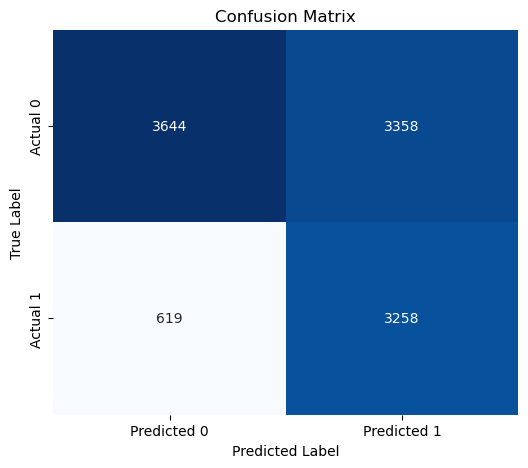

In [ ]:
# Class specific performance
plot_confusion_matrix(clf, test_X, test_y)

#### **b) Ridge Classifier**

In [ ]:
# Pipeline and hyperparameter space definition
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeClassifier(class_weight='balanced', random_state=42))
])

parameters = {
    'ridge__alpha': np.logspace(-3, 3, 20)
}

# Model training + hyperparameter tuning
clf_ridge = GridSearchCV(pipe_ridge, parameters, cv=5, scoring='balanced_accuracy')
clf_ridge.fit(train_X, train_y)

# Best parameters and evaluation metrics
print(f"Best Alpha: {clf_ridge.best_params_['ridge__alpha']}")
print(f"Best CV Accuracy: {clf_ridge.best_score_:.4f}")
print(f"Train Set Accuracy: {clf_ridge.score(train_X, train_y):.4f}")
print(f"Test Set Accuracy: {clf_ridge.score(test_X, test_y):.4f}")

c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:1306: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:1306: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:1306: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:1306: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to

Best Alpha: 6.158482110660261
Best CV Accuracy: 0.6837
Train Set Accuracy: 0.6841
Test Set Accuracy: 0.6808


In [ ]:
get_classification_metrics(clf_ridge, test_X, test_y)

{'Accuracy': 0.6341575512455189,
 'F1 Score': 0.6216010648412246,
 'ROC AUC': 0.7119736856936929,
 'F2 Score': 0.7379565668878956,
 'Recall': 0.8431777147278824,
 'Precision': 0.49224514380364404}

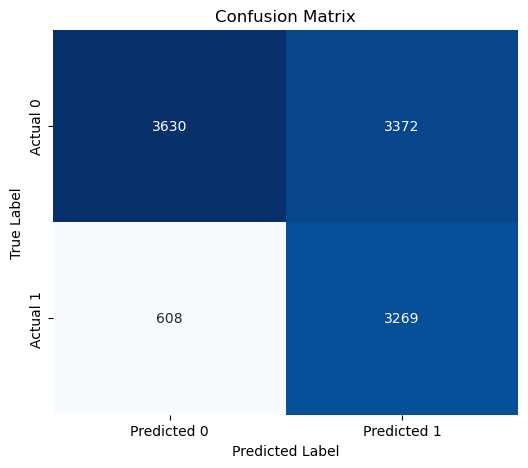

In [ ]:
plot_confusion_matrix(clf_ridge, test_X, test_y)

### **3.2 Support Vector Machine**

#### **a) Linear SVC**

In [ ]:
# Pipeline and hyperparameter space definition
svc_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', LinearSVC(random_state=42, max_iter=3000, dual='auto', class_weight='balanced'))
    ])

param_grid = {
        'svc__C': [0.0001, 0.0005, 0.001, 0.005, 0.01] # Redefined for finer search
    }
# Model training + hyperparameter tuning
svc = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    )

svc.fit(train_X, train_y.values.ravel())
# Best parameters, main evaluation metrics
print(f"Optimal SVC C: {svc.best_params_}")
print(f"Best SVC CV Score: {svc.best_score_:.4f}")
accuracy_train=svc.score(train_X, train_y)
print(f"Accuracy on train:{svc.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{svc.score(test_X, test_y):.4f}")

Optimal SVC C: {'svc__C': 0.01}
Best SVC CV Score: 0.6365
Accuracy on train:0.6371
Accuracy on test:0.6347


In [ ]:
get_classification_metrics(svc,test_X, test_y)

{'Accuracy': 0.6347090725250483,
 'F1 Score': 0.621883920076118,
 'ROC AUC': 0.7115937139298496,
 'F2 Score': 0.737997380425455,
 'Recall': 0.8429197833376322,
 'Precision': 0.492688074777627}

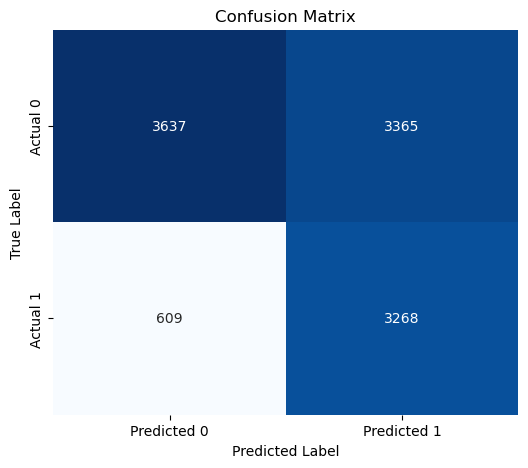

In [ ]:
plot_confusion_matrix(svc, test_X, test_y)


#### **b) SVM with Random Fourier Features (RBF-approximated SVM)**

We train our linear SVC in a transformed feature mapping (that uses random Fourier features) which provides an approximative mapping for the radial basis function kernel.

In [ ]:
# Pipeline and hyperparameter space definition
svc_rbf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('sampler', RBFSampler(random_state=42)),
    ('svc', LinearSVC(
        penalty='l2',
        max_iter=1000,
        random_state=42,
        dual=False,
        class_weight='balanced'))
])
# Model training + hyperparameter tuning
param_grid = {
    'sampler__gamma': np.logspace(-3, 1, 5),
    'svc__C': np.logspace(-3, 1, 5)
}
svm_rbf = GridSearchCV(
    estimator=svc_rbf_pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
# Best parameters, main evaluation metrics
svm_rbf.fit(train_X, train_y)
print(f"Best cross-validation accuracy: {svm_rbf.best_score_:.4f}")
print(f"Best parameters found: {svm_rbf.best_params_}")
print(f"Accuracy on train:{svm_rbf.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{svm_rbf.score(test_X, test_y):.4f}")

c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Best cross-validation accuracy: 0.6568
Best parameters found: {'sampler__gamma': 0.01, 'svc__C': 10.0}
Accuracy on train:0.6577
Accuracy on test:0.6569


In [ ]:
get_classification_metrics(svm_rbf, test_X, test_y)

{'Accuracy': 0.6568618439194779,
 'F1 Score': 0.6434915480851877,
 'ROC AUC': 0.7304942793528832,
 'F2 Score': 0.7621482218803728,
 'Recall': 0.8689708537529017,
 'Precision': 0.510919017288444}

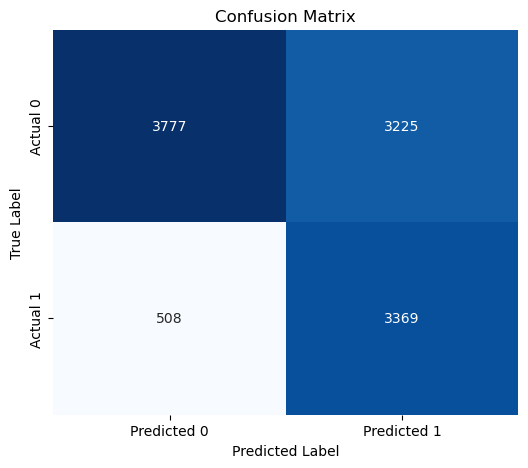

In [ ]:
plot_confusion_matrix(svm_rbf, test_X, test_y)

### **3.3 Ensemble methods**

#### **a) Random Forest**

In [ ]:
# Pipeline and hyperparameter space definition
rf = RandomForestClassifier(
    n_jobs=-1,
    oob_score=True,
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# Model training + hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1,
    refit=True
)

print("Starting Hyperparameter Tuning...")
grid_search.fit(train_X, train_y.values.ravel())
# Best parameters, main evaluation metrics
best_rf = grid_search.best_estimator_
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Accuracy on train:{best_rf.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{best_rf.score(test_X, test_y):.4f}")

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [ ]:
get_classification_metrics(best_rf, test_X, test_y)

{'Accuracy': 0.8649692067285596,
 'F1 Score': 0.810524958080743,
 'ROC AUC': 0.9427194684123192,
 'F2 Score': 0.8104622368964094,
 'Recall': 0.8104204281661078,
 'Precision': 0.8106295149638802}

In [ ]:
print(f"OOB Score: {best_rf.oob_score_:.4f}")

OOB Score: 0.8677


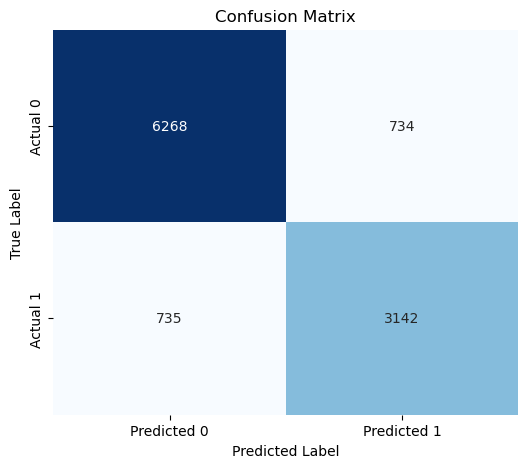

In [ ]:
plot_confusion_matrix(best_rf, test_X, test_y)

##### Feature Importance

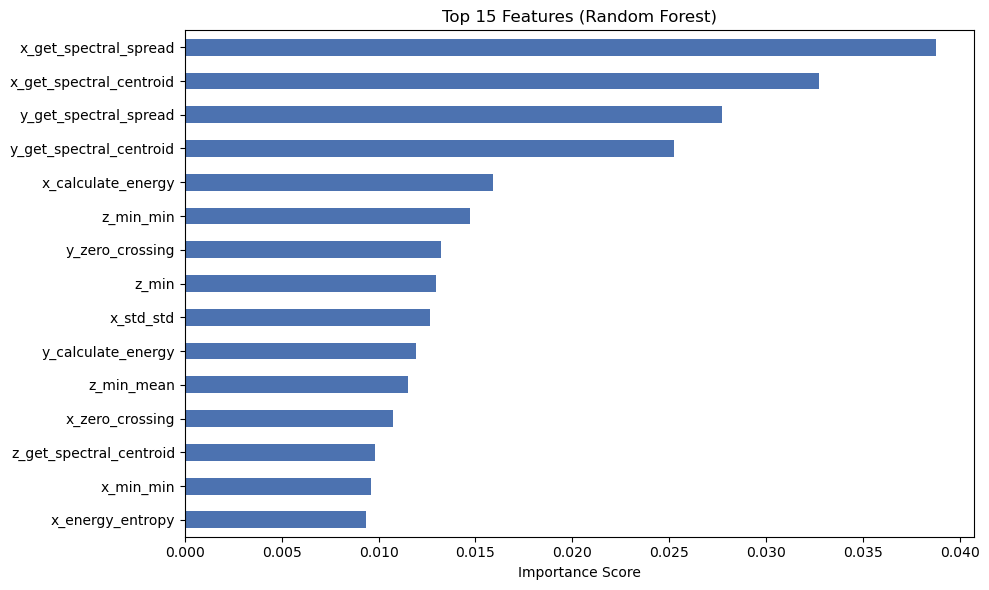

In [ ]:
importances = best_rf.feature_importances_

feature_names = train_X.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots(figsize=(10, 6))
forest_importances.nlargest(15).sort_values(ascending=True).plot.barh(ax=ax, color='#4c72b0')

ax.set_title("Top 15 Features (Random Forest)")
ax.set_xlabel("Importance Score")
fig.tight_layout()
plt.show()

#### **b) Adaboost**

In [ ]:
# Pipeline and hyperparameter space definition
pipe_ada = Pipeline([
    ('scaler', StandardScaler()),
    ('adaboost', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'),
        random_state=42
    ))
])

parameters_ada = {
    'adaboost__n_estimators': [200, 400, 600],
    'adaboost__learning_rate': [0.05, 0.1, 0.2],
    'adaboost__estimator__max_depth': [2, 3, 4]
}
# Model training + hyperparameter tuning
clf_ada = GridSearchCV(
    estimator=pipe_ada,
    param_grid=parameters_ada,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

clf_ada.fit(train_X, train_y.values.ravel())
# Best parameters, main evaluation metrics
print(f"Best Params: {clf_ada.best_params_}")
print(f"Best CV: {clf_ada.best_score_:.4f}")
print(f"Best cross-validation accuracy: {clf_ada.best_score_:.4f}")
print(f"Accuracy on train:{clf_ada.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{clf_ada.score(test_X, test_y):.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Params: {'adaboost__estimator__max_depth': 4, 'adaboost__learning_rate': 0.2, 'adaboost__n_estimators': 200}
Best CV F1: 0.7467
Best cross-validation accuracy: 0.7467
Accuracy on train:0.7486
Accuracy on test:0.7409


In [ ]:
get_classification_metrics(clf_ada, test_X, test_y)

{'Accuracy': 0.7408769188344517,
 'F1 Score': 0.6994989873147852,
 'ROC AUC': 0.8528236009358614,
 'F2 Score': 0.7807443365695793,
 'Recall': 0.8462728914108847,
 'Precision': 0.5961119186046512}

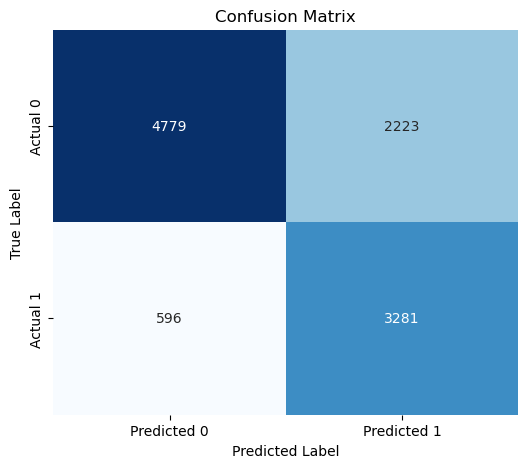

In [ ]:
plot_confusion_matrix(clf_ada, test_X, test_y)

#### **c) XGBoost**

In [ ]:
neg_count = (train_y.values.ravel() == 0).sum()
pos_count = (train_y.values.ravel() == 1).sum()
base_scale_pos_weight = neg_count / pos_count

In [ ]:
# Pipeline and hyperparameter space definition
xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_estimators=1000
    )

param_dist = {
        'n_estimators': [100, 250, 500, 750],
        'learning_rate': np.linspace(0.01, 0.3, 10),
        'max_depth': [3, 5, 7, 9, 12],
        'scale_pos_weight': [
        base_scale_pos_weight * 0.9,
        base_scale_pos_weight,
        base_scale_pos_weight * 1.1,
        base_scale_pos_weight * 1.5,
        base_scale_pos_weight * 2.0
    ]
    }
# Model training + hyperparameter tuning
random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist,
        n_iter=50,             # Number of unique combinations to try
        scoring='accuracy',
        cv=5,
        random_state=42,
        n_jobs=-1,
    )

random_search.fit(train_X, train_y.values.ravel())
# Best parameters, main evaluation metrics
print(f" Optimal XGBoost Parameters: {random_search.best_params_}")
print(f"Best XGBoost CV Score: {random_search.best_score_:.4f}")
best_xgb=random_search.best_estimator_
print(f"Accuracy on train:{best_xgb.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{best_xgb.score(test_X, test_y):.4f}")

c:\Users\mmlin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:20:07] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Optimal XGBoost Parameters: {'scale_pos_weight': 1.813968957871397, 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.10666666666666666}
Best XGBoost CV Score: 0.8705
Accuracy on train:0.9504
Accuracy on test:0.8642


In [ ]:
get_classification_metrics(best_xgb, test_X, test_y)

{'Accuracy': 0.8642338450225204,
 'F1 Score': 0.8139095376086682,
 'ROC AUC': 0.9465811087395568,
 'F2 Score': 0.8253270645952575,
 'Recall': 0.8331183905081249,
 'Precision': 0.7955665024630542}

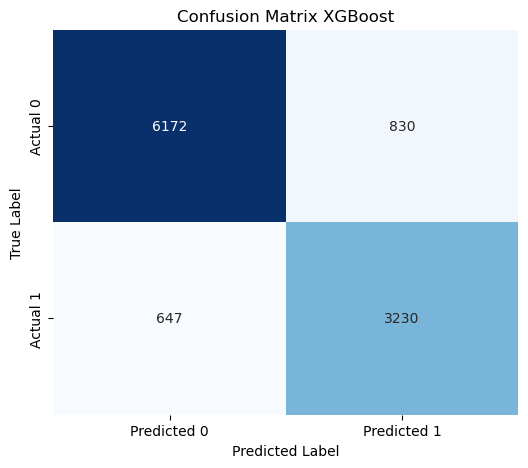

In [ ]:
plot_confusion_matrix(best_xgb, test_X, test_y, title="Confusion Matrix XGBoost")

##### Feature Importance

In [ ]:
importance_scores = best_xgb.feature_importances_
feature_names = best_xgb.get_booster().feature_names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df.head(10))

                    Feature  Importance
27    y_get_spectral_spread    0.088457
38       z_calculate_energy    0.058415
30                    z_min    0.050251
10       x_calculate_energy    0.037040
26  y_get_spectral_centroid    0.031393
12  x_get_spectral_centroid    0.029743
0                    x_mean    0.024223
21          y_percentile_75    0.023225
16                    y_min    0.020932
67              y_mean_mean    0.015533


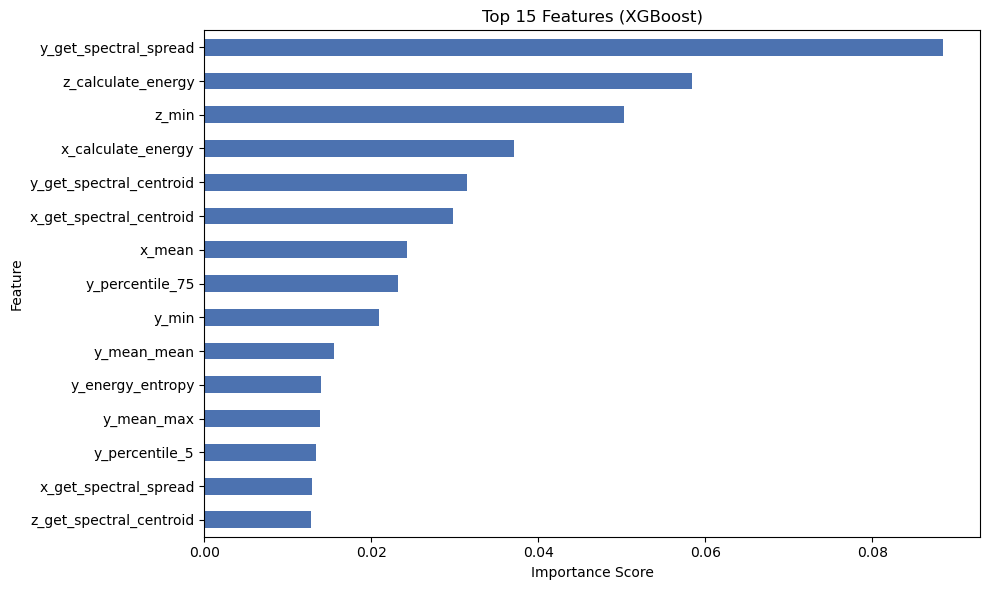

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = importance_df.nlargest(15, 'Importance').sort_values(by='Importance', ascending=True)
plot_df = plot_df.set_index('Feature')
plot_df['Importance'].plot.barh(ax=ax, color='#4c72b0')
ax.set_title("Top 15 Features (XGBoost)")
ax.set_xlabel("Importance Score")
fig.tight_layout()
plt.show()

#### **d) Stacked Ensemble**

In [ ]:
estimators = [
    ('rf', best_rf),
    ('xgboost', best_xgb)]

In [ ]:
# Pipeline and hyperparameter space definition
stacked_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42)
)
param_grid = {
    'final_estimator__C': [0.1, 1.0, 10.0]
}
# Model training + hyperparameter tuning
grid_search = GridSearchCV(
    estimator=stacked_clf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

stacked=grid_search.fit(train_X, train_y)

c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:26] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mmlin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:30:27] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\

In [ ]:
# Best parameters, main evaluation metrics
print(f" Optimal Stacked Parameter: {grid_search.best_params_}")
print(f"Best Stacked CV Score: {grid_search.best_score_:.4f}")
print(f"Accuracy on train:{stacked.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{stacked.score(test_X, test_y):.4f}")

 Optimal Stacked Parameter: {'final_estimator__C': 0.1}
Best Stacked CV Score: 0.8676
Accuracy on train:0.9504
Accuracy on test:0.8665


In [ ]:
get_classification_metrics(stacked, test_X, test_y)

{'Accuracy': 0.8665318503538928,
 'F1 Score': 0.8105922254109053,
 'ROC AUC': 0.9457781398100118,
 'F2 Score': 0.805047416696896,
 'Recall': 0.801392829507351,
 'Precision': 0.8200052784375825}

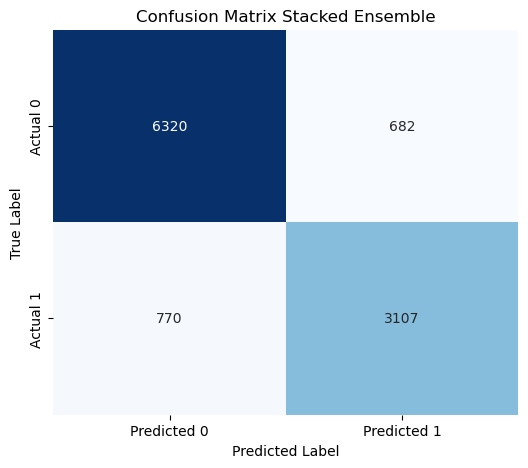

In [ ]:
plot_confusion_matrix(stacked, test_X, test_y, title="Confusion Matrix Stacked Ensemble")

#### **e) Voting Classifier**

In [ ]:
# Model definition
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft'
)
# Model training
voting_clf.fit(train_X, train_y)
# Main evaluation metrics
print(f"Accuracy on train:{voting_clf.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{voting_clf.score(test_X, test_y):.4f}")

c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
c:\Users\mmlin\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:31:55] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy on train:0.9504
Accuracy on test:0.8665


In [ ]:
get_classification_metrics(voting_clf, test_X, test_y)

{'Accuracy': 0.8665318503538928,
 'F1 Score': 0.8162025316455697,
 'ROC AUC': 0.946591054680055,
 'F2 Score': 0.825354564538426,
 'Recall': 0.8315708021666237,
 'Precision': 0.8013919960228685}

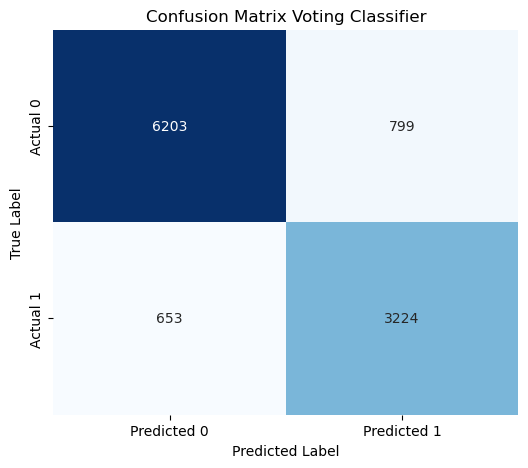

In [ ]:
plot_confusion_matrix(voting_clf, test_X, test_y, title="Confusion Matrix Voting Classifier")

### **3.4 Artificial Neural Networks**

#### **a) Multi-Layer Perceptron**

In [ ]:
# Pipeline and hyperparameter space definition
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1000, random_state=42))
])

parameters_mlp = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__activation': ['relu', 'tanh']
}
# Model training + hyperparameter tuning
clf_mlp = GridSearchCV(pipe_mlp, parameters_mlp, cv=5, n_jobs=-1)
clf_mlp.fit(train_X, train_y.values.ravel())

# Best parameters, main evaluation metrics
print(f" Optimal MLP Parameters: {clf_mlp.best_params_}")
print(f"Best MLP CV Score: {clf_mlp.best_score_:.4f}")
best_mlp=clf_mlp.best_estimator_
print(f"Accuracy on train:{best_mlp.score(train_X, train_y):.4f}")
print(f"Accuracy on test:{best_mlp.score(test_X, test_y):.4f}")

 Optimal MLP Parameters: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (50, 50)}
Best MLP CV Score: 0.7274
Accuracy on train:0.8349
Accuracy on test:0.7754


In [ ]:
get_classification_metrics(best_mlp, test_X, test_y)

{'Accuracy': 0.7754389190182921,
 'F1 Score': 0.6612120371654416,
 'ROC AUC': 0.8423844891363439,
 'F2 Score': 0.632629232565545,
 'Recall': 0.6149084343564611,
 'Precision': 0.7150569886022795}

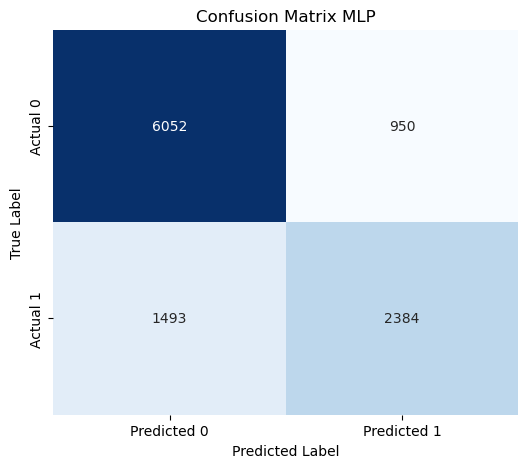

In [ ]:
plot_confusion_matrix(best_mlp, test_X, test_y, title="Confusion Matrix MLP")

## **4. Model Comparison Across Different Thresholds**

We assess models performance across different classification thresholds. We focus on :
- The trade-off between specificity and sensitivity using the ROC-AUC curve.
- The trade-off between precision and recall using the precision-recall curve.

In [ ]:
models=[clf, clf_ridge, svc, svm_rbf,best_rf, clf_ada, best_xgb,  best_mlp, stacked, voting_clf]
model_names=["Logistic Regression","Ridge Classifier", "Linear SVC","SVM-RBF", "Random Forest", "AdaBoost", "XGBoost", "MLP", "Stacked Ensemble", "Voting Classifier"]

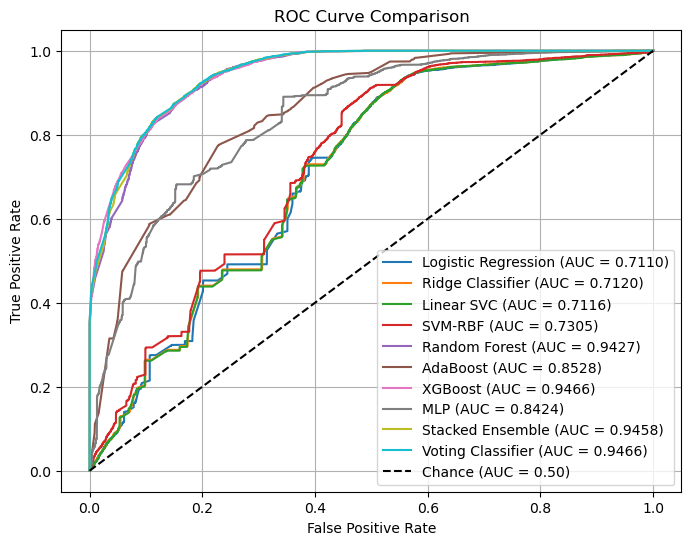

In [ ]:
plot_roc_curve_comparison(models, test_X, test_y, model_names)

c:\Users\mmlin\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
C:\Users\mmlin\AppData\Local\Temp\ipykernel_6472\815918799.py:113: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prevalence = float(np.sum(y_test) / len(y_test))


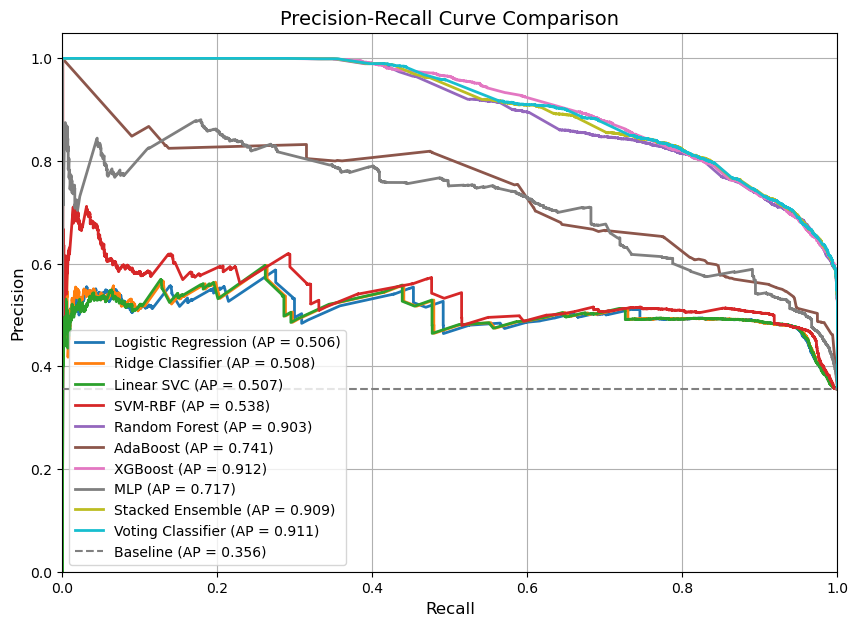

In [ ]:
plot_precision_recall_curves(models, test_X, test_y, models_names=model_names)

## **5. Visualisations**

We know want to better characterize where our two best performing models, Random Forest and XGBoost, are failing : which cases are they missing and are these 'serious' mistakes. We plot the distribution of the raw Transdermal Alcohol Content (TAC) values for the False Positives and False Negatives of both best performing models.

#### **a) False Positives and False Negatives Distribution for XGBoost**

In [ ]:
# We build a new data frame containing : tests data - features and target - XGBoost predictions and raw TAC readings
y_pred = best_xgb.predict(test_X) # Get XGBoost predictions on test
results_df = test_X.copy() # New df

# Recover TAC readings from the original df
test_tac_values = df.loc[results_df.index, "TAC_Reading"]
results_df['TAC_Reading'] = test_tac_values

# Get true and predicted labels
results_df['True_Label'] = test_y
results_df['Predicted_Label'] = y_pred

In [ ]:
# Isolate False Positives and False Negatives samples
# Get False Positives
fp_samples = results_df[
    (results_df['True_Label'] == 0) & (results_df['Predicted_Label'] == 1)
]
fp_tac = fp_samples['TAC_Reading'] # Extract the TAC values

# Get False Negatives
fn_samples = results_df[
    (results_df['True_Label'] == 1) & (results_df['Predicted_Label'] == 0)
]
fn_tac = fn_samples['TAC_Reading'] # Extract the TAC values

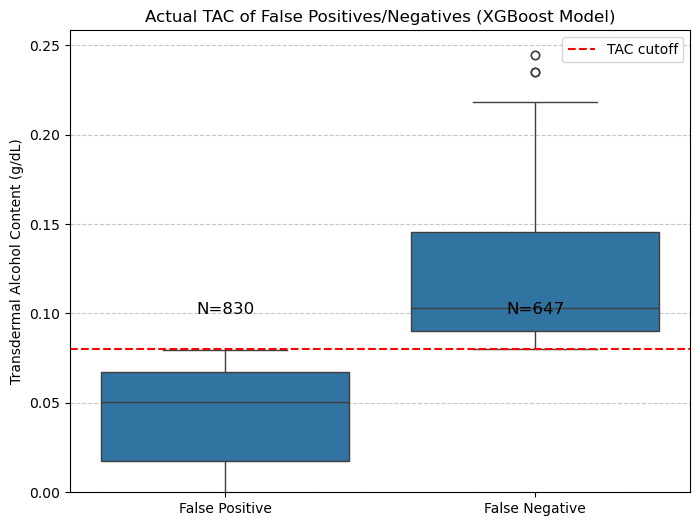

In [ ]:
# Produce a box plot for TAC recordings for False Positives and False Negatives separately
# Combine the data for plotting
plot_data = pd.DataFrame({
    'TAC': pd.concat([fp_tac, fn_tac]),
    'Error Type': (
        ['False Positive'] * len(fp_tac) +
        ['False Negative'] * len(fn_tac)
    )
})

# Define the TAC cutoff value
TAC_CUTOFF = 0.08

plt.figure(figsize=(8, 6))
ax = sns.boxplot(
    x='Error Type',
    y='TAC',
    data=plot_data,
    order=['False Positive', 'False Negative'],
    showfliers=True
)
# Add the TAC cutoff line
ax.axhline(TAC_CUTOFF,
           color='red',
           linestyle='--',
           label='TAC cutoff')
# Add N labels
ax.text(0, 0.10, f'N={len(fp_tac)}', ha='center', fontsize=12)
ax.text(1, 0.10, f'N={len(fn_tac)}', ha='center', fontsize=12)

ax.set_xlabel('')
ax.set_ylabel('Transdermal Alcohol Content (g/dL)')
ax.set_title('Actual TAC of False Positives/Negatives (XGBoost Model)')
plt.legend()
plt.ylim(bottom=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(fp_tac.describe())

count    830.000000
mean       0.043858
std        0.028479
min       -0.028308
25%        0.017438
50%        0.050424
75%        0.067269
max        0.079528
Name: TAC_Reading, dtype: float64


In [ ]:
print(fn_tac.describe())

count    647.000000
mean       0.120786
std        0.039229
min        0.080089
25%        0.089984
50%        0.103274
75%        0.145695
max        0.244715
Name: TAC_Reading, dtype: float64


#### **b) False Positives and False Negatives Distribution for Random Forest**

As above, we build a new dataset containing the test data - features and target - the predictions and the raw TAC readings. We isolate those instances classified as false positives and false negatives and plot their TAC reading distribution.

In [ ]:
# We build a new data frame containing : tests data - features and target - Random Forest predictions and raw TAC readings
y_pred = best_rf.predict(test_X)
results_df = test_X.copy()

# Add TAC Readings to test data
test_tac_values = df.loc[results_df.index, "TAC_Reading"]
results_df['TAC_Reading'] = test_tac_values
# Add true and predicted labels
results_df['True_Label'] = test_y
results_df['Predicted_Label'] = y_pred

In [ ]:
# Isolate False Positives and False Negatives samples
# Get False Positives
fp_samples = results_df[
    (results_df['True_Label'] == 0) & (results_df['Predicted_Label'] == 1)
]
fp_tac = fp_samples['TAC_Reading'] # Extract the TAC values

# Get False Negatives
fn_samples = results_df[
    (results_df['True_Label'] == 1) & (results_df['Predicted_Label'] == 0)
]
fn_tac = fn_samples['TAC_Reading'] # Extract the TAC values

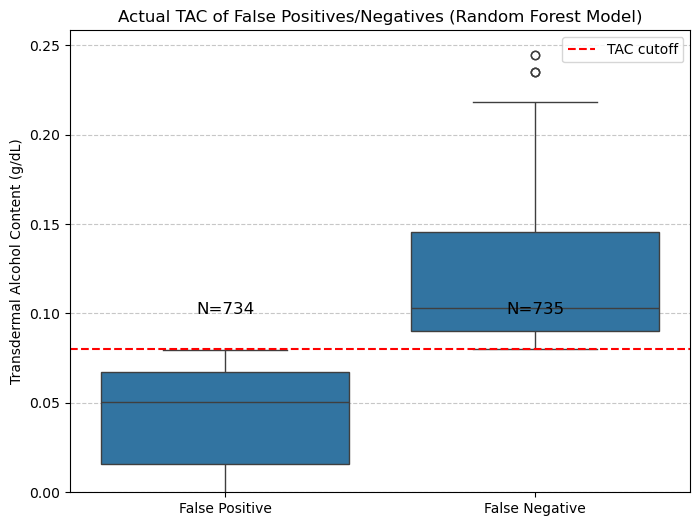

In [ ]:
# Produce a box plot for TAC recordings for False Positives and False Negatives separately
# Combine the data for plotting
plot_data = pd.DataFrame({
    'TAC': pd.concat([fp_tac, fn_tac]),
    'Error Type': (
        ['False Positive'] * len(fp_tac) +
        ['False Negative'] * len(fn_tac)
    )
})

# Define the TAC cutoff value
TAC_CUTOFF = 0.08

plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x='Error Type',
    y='TAC',
    data=plot_data,
    order=['False Positive', 'False Negative'],
    showfliers=True
)

# Add the TAC cutoff line
ax.axhline(TAC_CUTOFF,
           color='red',
           linestyle='--',
           label='TAC cutoff')

# Add N labels
ax.text(0, 0.10, f'N={len(fp_tac)}', ha='center', fontsize=12)
ax.text(1, 0.10, f'N={len(fn_tac)}', ha='center', fontsize=12)

ax.set_xlabel('')
ax.set_ylabel('Transdermal Alcohol Content (g/dL)')
ax.set_title('Actual TAC of False Positives/Negatives (Random Forest Model)')
plt.legend()
plt.ylim(bottom=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(fp_tac.describe())

count    734.000000
mean       0.043298
std        0.029177
min       -0.028308
25%        0.015652
50%        0.050424
75%        0.067269
max        0.079528
Name: TAC_Reading, dtype: float64


In [ ]:
print(fn_tac.describe())

count    735.000000
mean       0.120545
std        0.038874
min        0.080089
25%        0.089984
50%        0.103274
75%        0.145695
max        0.244715
Name: TAC_Reading, dtype: float64


#### **c) Feature distribution analyses for misclassified samples:**

In [ ]:
# --- SETUP: Define Groups ---
def get_group(row, pred_col):
    tac = row['TAC']
    pred = row[pred_col]

    # 1. Baseline Sober (True Negative)
    if tac < 0.01 and pred == 0:
        return '1. Baseline Sober (TN)'

    # 2. Early Ataxia (False Positive)
    elif (0.04 <= tac < 0.08) and pred == 1:
        return '2. False Positive (FP)'

    # 3. True Intoxicated (True Positive)
    elif tac >= 0.08 and pred == 1:
        return '3. True Intoxicated (TP)'

    return None

# --- PREPARE DATA ---
# Create a working dataframe with features, ground truth, and predictions
data = test_X.copy()
data['TAC'] = df.loc[test_X.index, 'TAC_Reading']
data['Pred_RF'] = best_rf.predict(test_X)
data['Pred_XGB'] = best_xgb.predict(test_X)

# Assign groups based on predictions and TAC levels
data['Group_RF'] = data.apply(lambda row: get_group(row, 'Pred_RF'), axis=1)
data['Group_XGB'] = data.apply(lambda row: get_group(row, 'Pred_XGB'), axis=1)

# --- PLOT 1: RANDOM FOREST  ---
rf_features = [
    ('x_get_spectral_spread', 'X Spectral Spread'),
    ('x_get_spectral_centroid', 'X Spectral Centroid'),
    ('y_get_spectral_spread', 'Y Spectral Spread')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_data_rf = data.dropna(subset=['Group_RF']).sort_values('Group_RF')

for i, (col, title) in enumerate(rf_features):
    sns.boxplot(data=plot_data_rf, x='Group_RF', y=col, ax=axes[i], showfliers=False, palette="Blues")
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Random Forest: Physiological Validation of "False Positives"', fontsize=16)
plt.tight_layout()
plt.show()

# --- PLOT 2: XGBOOST ---
xgb_features = [
    ('y_get_spectral_spread', 'Y Spectral Spread\n(Lateral Sway Chaos)'),
    ('z_calculate_energy', 'Z Energy\n(Vertical Intensity)'),
    ('z_min', 'Z Minimum\n(Impact/Heel Strike)')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_data_xgb = data.dropna(subset=['Group_XGB']).sort_values('Group_XGB')

for i, (col, title) in enumerate(xgb_features):
    sns.boxplot(data=plot_data_xgb, x='Group_XGB', y=col, ax=axes[i], showfliers=False, palette="Reds")
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

    # Add reference line for Z-Min to visualize impact differences
    if col == 'z_min':
        baseline = plot_data_xgb[plot_data_xgb['Group_XGB'] == '1. Baseline Sober (TN)'][col].median()
        axes[i].axhline(baseline, color='black', linestyle='--', linewidth=2, label='Sober Median')
        axes[i].legend()

plt.suptitle('XGBoost: Physiological Validation of "False Positives"', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# --- SETUP: Define Groups ---
def get_group(row, pred_col):
    tac = row['TAC']
    pred = row[pred_col]

    # 1. Baseline Sober (True Negative)
    if tac < 0.01 and pred == 0:
        return '1. Baseline Sober (TN)'

    # 2. Hyperactive Intoxicated (False Negative)
    elif (tac >= 0.08) and pred == 0:
        return '2. False Negative (FN)'

    # 3. True Intoxicated (True Positive)
    elif tac >= 0.08 and pred == 1:
        return '3. Standard Intoxicated (TP)'

    return None

# --- PREPARE DATA ---
# Create a working dataframe with features, ground truth, and predictions
data = test_X.copy()
data['TAC'] = df.loc[test_X.index, 'TAC_Reading']
data['Pred_RF'] = best_rf.predict(test_X)
data['Pred_XGB'] = best_xgb.predict(test_X)

# Assign groups based on predictions and TAC levels
data['Group_RF'] = data.apply(lambda row: get_group(row, 'Pred_RF'), axis=1)
data['Group_XGB'] = data.apply(lambda row: get_group(row, 'Pred_XGB'), axis=1)

# --- PLOT 1: RANDOM FOREST  ---
rf_features = [
    ('x_get_spectral_spread', 'X Spectral Spread'),
    ('x_get_spectral_centroid', 'X Spectral Centroid'),
    ('y_get_spectral_spread', 'Y Spectral Spread')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_data_rf = data.dropna(subset=['Group_RF']).sort_values('Group_RF')

for i, (col, title) in enumerate(rf_features):
    sns.boxplot(data=plot_data_rf, x='Group_RF', y=col, ax=axes[i], showfliers=False, palette="Blues")
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Random Forest: Physiological Validation of "False Negatives"', fontsize=16)
plt.tight_layout()
plt.show()

# --- PLOT 2: XGBOOST ---
xgb_features = [
    ('y_get_spectral_spread', 'Y Spectral Spread'),
    ('z_calculate_energy', 'Z Energy'),
    ('z_min', 'Z Minimum')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_data_xgb = data.dropna(subset=['Group_XGB']).sort_values('Group_XGB')

for i, (col, title) in enumerate(xgb_features):
    sns.boxplot(data=plot_data_xgb, x='Group_XGB', y=col, ax=axes[i], showfliers=False, palette="Reds")
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

    # Add reference line for Z-Min to visualize impact differences
    if col == 'z_min':
        baseline = plot_data_xgb[plot_data_xgb['Group_XGB'] == '1. Baseline Sober (TN)'][col].median()
        axes[i].axhline(baseline, color='black', linestyle='--', linewidth=2, label='Sober Median')
        axes[i].legend()

plt.suptitle('XGBoost: Physiological Validation of "False Negatives"', fontsize=16)
plt.tight_layout()
plt.show()